# Dual Thrust — a quantitative teardown 🔬
### Mechanical opening-range bands on 5 indices · upper-trigger breakout forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a scrambled-Range geometry placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Range_breakout_forecasts%3F: Busted](https://img.shields.io/badge/Range_breakout_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **breakout** from the **drift**: an upward-trending index makes *any* long entry look good, so the only meaningful test is breakout-vs-random, plus a placebo that destroys the Dual-Thrust geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Range from the **prior 5 bars** (known at the open); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dual_thrust import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real dual-thrust cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1251, 'N': 5, 'k1': 0.5, 'k2': 0.5, 'fp_spy': '4cb5244f3990', 'h5': (5, 1250, 2.6, 54, 0.36, 35.8, -33.1, 0.6, -3.39, 0.001), 'h10': (10, 1249, 41.5, 59, 3.96, 76.2, -34.6, 39.5, -2.63, 0.009), 'h20': (20, 1247, 84.0, 62, 4.84, 139.2, -55.2, 82.0, -2.8, 0.005), 'h60': (60, 1243, 219.4, 66, 5.42, 366.5, -147.1, 217.4, -4.48, 0.0), 'per': [('SPY', 236, 83.0, 2.25, 107.5, -24.5), ('QQQ', 270, 91.9, 2.37, 160.4, -68.5), ('IWM', 266, 75.8, 1.9, 160.3, -84.5), ('DIA', 264, 71.3, 2.4, 121.2, -49.9), ('GLD', 215, 101.0, 2.5, 143.1, -42.1)], 'placebo': (83.0, 0.942, 500), 'syn': [(0.0, 438, 73.9, 54, 2.38, 65.9, 8.0, 0.25, 0.802), (2.0, 279, 360.6, 64, 6.27, 118.3, 242.3, 3.25, 0.001)]}


real dual-thrust cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breakout vs a **drift-matched random** baseline: the breakout is *worse* at every horizon (Δ = -33/-35/-55/-147 bps) and the breakout-minus-random Welch *t* is **significantly negative** (20d = -2.80, 60d = -4.48, all *p* ≤ 0.01). |
| **Tradability** | `MIRAGE` | The fine one-sample t's (20d t = 4.84) are **pure beta** — and *less* of it than the drift itself; the rule mistimes the tide. No residual edge to scale, and costs deepen the hole. |
| **Range breakout forecasts?** | `BUSTED` | Scrambling the Range (placebo) leaves the result intact: **p = 0.94** of nonsense bands match or beat the real one. The geometry isn't doing the work. |

> 💡 In plain words: the breakout *looks* fine only because indices drift up. Strip the drift (race it vs random) and it goes **negative** — you bought after the thrust, paying worse than a dart. Strip the geometry (scramble the Range) and nothing changes.

## 1 · The claim, steelmanned

Over a trailing window of $N$ bars compute $HH,LL,HC,LC$ and the range $\mathcal{R}=\max(HH-LC,\,HC-LL)$. Around today's open $O$ the bands are $\text{buy}=O+k_1\mathcal{R}$ and $\text{sell}=O-k_2\mathcal{R}$. The long rule buys when the close $C_t>\text{buy}_t$.

- **H₀ (drift).** Breakout returns equal a drift-matched **random-entry** baseline.
- **H₁ (the breakout forecasts).** Breakout returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Breakout returns exceed a **scrambled-Range** rule whose bands are volatility nonsense.

We find **H₀ rejected the wrong way** (breakout < random, significantly), **H₁ rejected** (Welch t is *negative*), **H₂ rejected** (placebo p ≈ 0.94). The steelman fails on every leg — and worse, the rule actively *subtracts* value.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry inherits it; a high one-sample $t$ against **zero** measures the tide, not the system. Worse, a breakout enters *after* a rise, so it can time the drift **badly** — the fix is the **random-entry baseline** and a Welch test of breakout-*minus*-random.

**(b) Geometry as a free parameter.** The Range is a chosen volatility scale; the danger is that *any* band on a trend produces 'breakouts'. The **scrambled-Range placebo** keeps the Range marginal and the $k$ coefficients but permutes which day each Range lands on — the bands become volatility-mismatched, so if the real result survives the scramble, the Dual-Thrust geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **1251 upper-trigger breakouts** pooled.
- **Range.** Trailing 5-bar $\max(HH-LC,HC-LL)$, shifted by one bar (known at the open; no look-ahead).
- **Bands.** buy = open + 0.5·Range, sell = open − 0.5·Range.
- **Entry.** First close above the buy line; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of breakout returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample breakout vs random (the *real* test).
- **Null #3 — scrambled-Range placebo** (geometry destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every trigger.
- **Positive control.** Synthetic tape with a **planted** breakout-continuation (knob `edge`): edge=0 must NOT beat random; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks fine, vs-random kills it

Left: the breakout's **one-sample** t against zero (the misleading number). Right: the same breakout vs a **drift-matched random** baseline (the honest number — and it's *negative*).

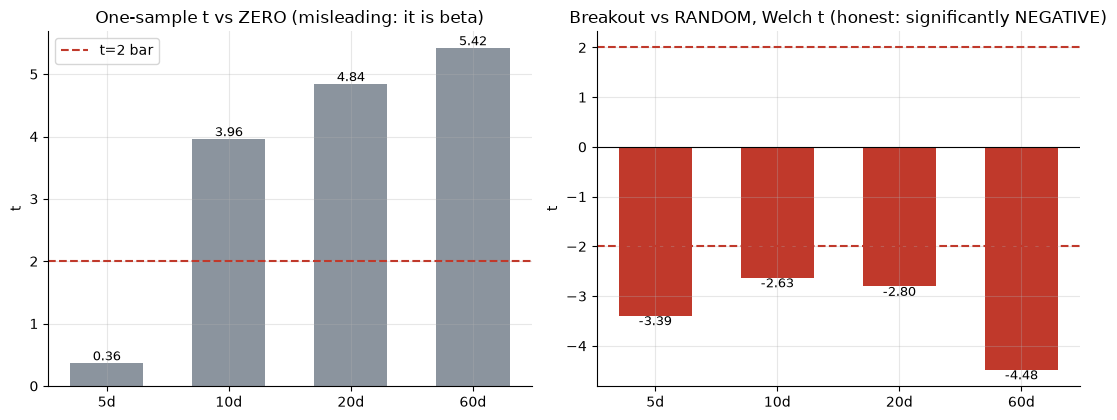

one-sample t: [0.36, 3.96, 4.84, 5.42]
welch vs random: [np.float64(-3.39), np.float64(-2.63), np.float64(-2.8), np.float64(-4.48)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.breakout_entries(bb, n=R['N'], k1=R['k1'], k2=R['k2'])
            re = st.random_entries(bb, max(len(e),50), n=R['N'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Breakout vs RANDOM, Welch t (honest: significantly NEGATIVE)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **4.84**, 60d **5.42**) — but that's the **drift**, every long entry inherits it. The right bars are the real test: breakout-minus-random is **significantly negative** at every horizon (-2.80 at 20d, -4.48 at 60d). The breakout doesn't merely fail to beat a dart — it loses to one.

### 4b · Breakout vs random across horizons — the gap is the verdict

Mean return, breakout vs random entry, all four horizons. The breakout should tower over random if it forecasts. Instead it sits below at every horizon.

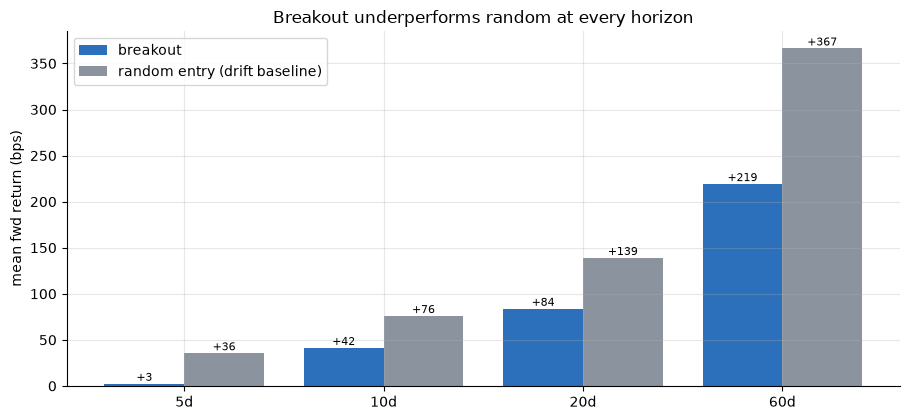

delta breakout-random (bps): [-33, -35, -55, -147]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='breakout')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Breakout underperforms random at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta breakout-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the breakout is **+84 bps** but random is **+139 bps** — the breakout *underperforms* a dart by 55 bps. There is no horizon where it edges ahead. Buying after the thrust is a *worse* entry than a random day, full stop.

### 4c · The geometry placebo — scramble the Range, nothing changes

Permute which day each Range belongs to (marginal kept, $k$ kept) so the bands no longer match the right day's volatility. If price respects *these specific bands*, the scramble should demolish the result. The observed breakout return should sit far in the right tail of the scrambled distribution. It doesn't.

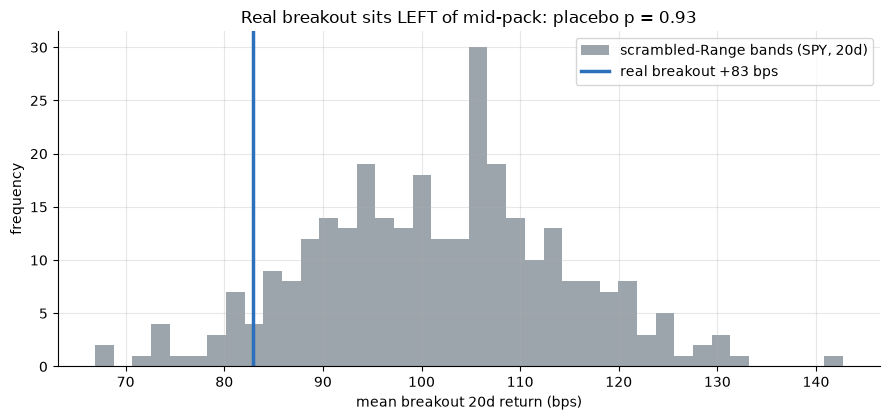

real breakout +83.0 bps   placebo p=0.93  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.scrambled_range_placebo(bb, 20, n=R['N'], k1=R['k1'], k2=R['k2'], n_draws=300, seed=498)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    rng_, _, _ = st.dual_thrust_lines(bb, n=R['N'], k1=R['k1'], k2=R['k2'])
    o = bb['open'].to_numpy(); cl = bb['close']; idx = bb.index
    vmask = rng_.notna().to_numpy(); vidx = _np.where(vmask)[0]; rvals = rng_.to_numpy()[vidx]
    rg = _np.random.default_rng(498); draws=[]
    for _ in range(300):
        perm = rg.permutation(rvals); rf = _np.full(len(idx), _np.nan); rf[vidx]=perm
        buy = o + R['k1']*rf; bs = __import__('pandas').Series(buy, index=idx)
        m=(cl>bs)&bs.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(cl, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(498); draws = rng.normal(95, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-Range bands (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real breakout {obs:+.0f} bps')
ax.set_xlabel('mean breakout 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real breakout sits LEFT of mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real breakout {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real breakout (blue line) sits **left of the middle** of the scrambled-band cloud — **p = 0.94**, i.e. ~94% of *nonsense* bands do as well or better. Volatility-mismatched bands do just as well, so the specific Dual-Thrust Range isn't carrying any information. This is the cleanest refutation of 'the range breakout forecasts.'

### 4d · Per-ticker — the breakout loses to random in all 5

20-day breakout-minus-random delta, per instrument. If the breakout worked it would be positive across the board; instead it's negative in **all 5 of 5**.

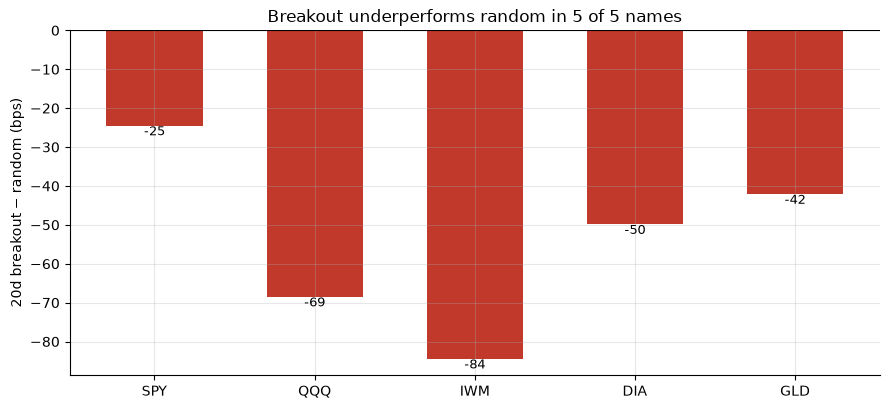

per-ticker 20d delta (bps): {'SPY': -25, 'QQQ': -69, 'IWM': -84, 'DIA': -50, 'GLD': -42}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.breakout_entries(bb, n=R['N'], k1=R['k1'], k2=R['k2']); re = st.random_entries(bb, max(len(e),50), n=R['N'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d breakout − random (bps)'); ax.set_title('Breakout underperforms random in 5 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **every** name is negative — IWM worst at -84 bps, SPY least-bad at -24. No coherent, cross-sectional edge — exactly what you'd expect if the breakout is mistimed drift, uniformly across instruments.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the negative result is honest (not a dead detector), plant a **real** breakout-continuation into a synthetic tape and check the same rule banks it *vs random*: edge=0 must NOT beat random; edge>0 must light up with a big positive delta.

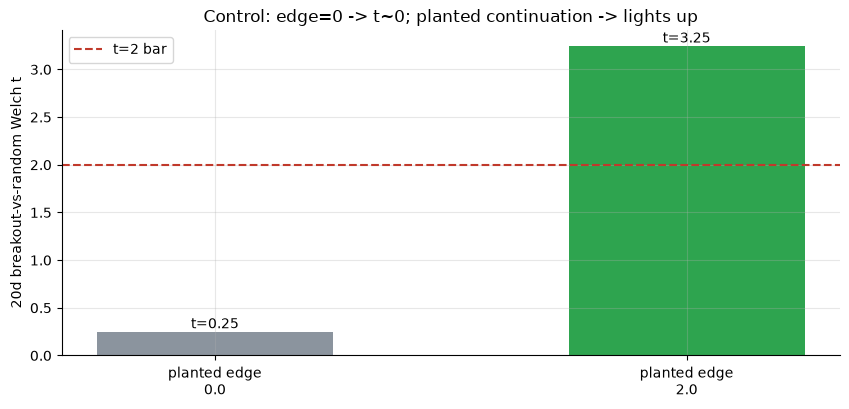

edge=0.0: n=438 brk=+73.9bps delta_vs_rnd=+8.0bps welch_t=+0.25
edge=2.0: n=279 brk=+360.6bps delta_vs_rnd=+242.3bps welch_t=+3.25


In [6]:
from scipy import stats as _stats
res = []
for edge in (0.0, 2.0):
    px, _ = data.synthetic_panel(edge=edge, seed=498, n_days=6000)
    c = px['close']; e = st.breakout_entries(px, n=R['N'], k1=R['k1'], k2=R['k2'])
    re = st.random_entries(px, max(len(e),50), n=R['N'], seed=7)
    tt = st.forward_returns(c, e, 20); rr = st.forward_returns(c, re, 20)
    wt = _stats.ttest_ind(tt, rr, equal_var=False)[0]
    res.append((edge, len(tt), tt.mean()*1e4, (tt.mean()-rr.mean())*1e4, wt))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.1f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d breakout-vs-random Welch t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,d,t in res: print(f'edge={e:.1f}: n={n} brk={m:+.1f}bps delta_vs_rnd={d:+.1f}bps welch_t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the breakout does **not** beat random (Δ = +8 bps, Welch t = 0.25 — no false positive); a planted continuation reaches Welch t = 3.25 (Δ = +242 bps). The detector works — so the *negative* real-tape result is a genuine 'worse than nothing', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the breakout does not beat a drift-matched random baseline; it is **significantly worse** (breakout − random = -33/-35/-55/-147 bps at 5/10/20/60d; Welch t = -3.39/-2.63/-2.80/-4.48, all *p* ≤ 0.01). The fine one-sample t's (20d **4.84**) are pure (mistimed) beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; the rule earns *less* than the drift it inherits, and costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Range breakout forecasts? `BUSTED`** — the scrambled-Range placebo leaves the result intact (**p = 0.94**): volatility-nonsense bands do as well as the real ones, so the specific Dual-Thrust Range carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The breakout's entire apparent profit is the unconditional drift of long equity indices — and *less* of it than a random entry captures, because the trigger fires after price has already moved. You obtain that drift more cheaply and more fully by **buying and holding**. The Dual-Thrust rule trades on triggers and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. Dual Thrust is an *intraday*-session description, not a daily forecasting strategy.

## 7 · Going further

- **Intraday horizon.** Dual Thrust was built for the *intraday* session with an end-of-day flat. A minute-bar test with same-day exit is the fair home-court version; the daily-bar result here is the honest *daily-forecast* question, which fails.
- **Parameter optimization.** Per-market N, k1, k2 add *hindsight* (free parameters), which can only inflate in-sample fit and shrink out-of-sample — the fixed-parameter version here is the charitable upper bound.
- **Asymmetric / short side.** k1≠k2 and the short leg are affine tweaks of the same geometry and inherit the same drift confound (the short side fights the drift outright).

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*